In [1]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [ ]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import graph_utils
from ESMCBA import other_utils
import importlib
importlib.reload(other_utis)
from pathlib import Path
from sklearn.metrics import mean_squared_error

In [3]:
pd.set_option('display.max_columns', 100)

In [4]:
evaluations = pd.read_csv('../evaluations_full_02062025.csv')

Processed 44 alleles successfully
Retained 4308 data points with ≥2 replicates
Analyzing 22 unique HLAs across 8 regimes

Fitting mixed-effects model...
  ✓ PT H 30L: converged
  ✓ PT E 30L: converged
  ✓ Non-PT E 0L: converged
  ✓ Non-PT H 0L: converged
  ✓ Non-PT H 30L: converged
  ✓ PT E 0L: converged
  ✓ Non-PT E 30L: converged
  ✓ PT H 0L: converged

Generating predictions with bootstrap CIs...


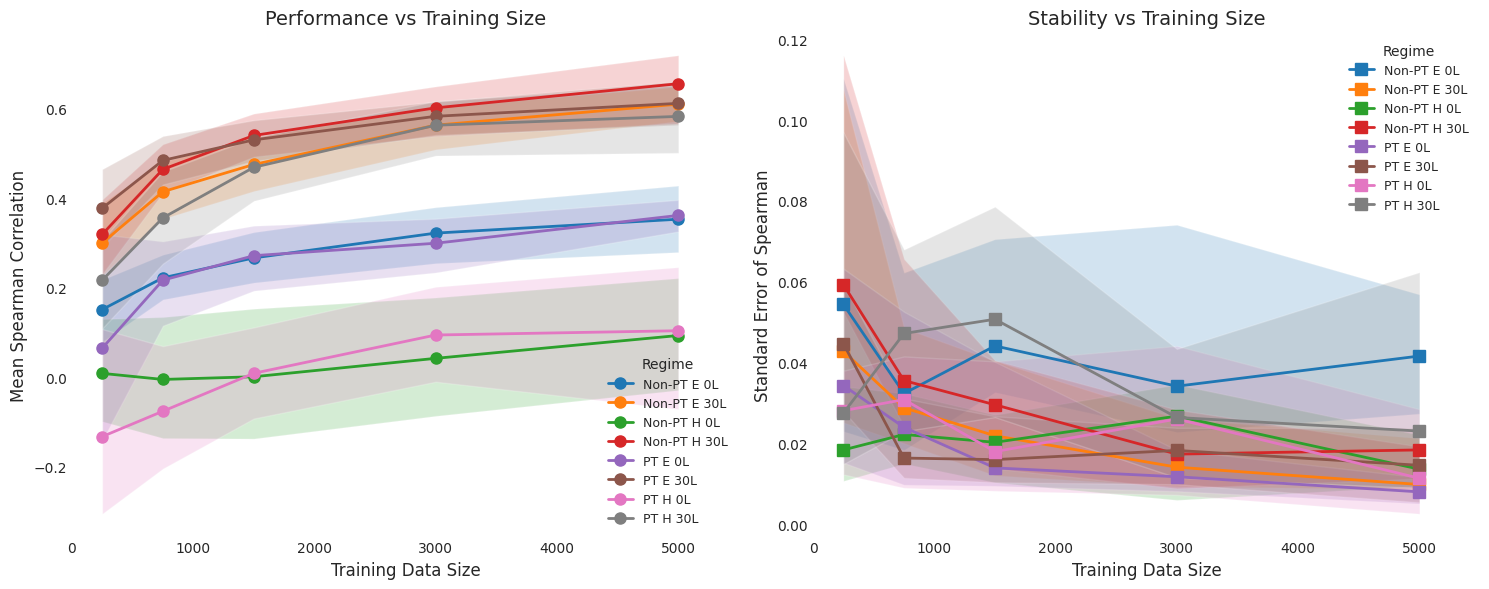

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error
from scipy import stats
import statsmodels.formula.api as smf
from scipy.stats import bootstrap
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    'min_replicates': 2,
    'min_test_samples': 2,
    'year_cutoff_primary': 2019,
    'year_cutoff_fallback': 1995,
    # Plot points for visualization (equivalent to original bin centers)
    'plot_points': [250, 750, 1500, 3000, 5000],
    'confidence_level': 0.95,
    'bootstrap_iterations': 5000
}

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def fisher_z_transform(r):
    """Fisher Z transformation for correlation coefficients"""
    # Clip to avoid numerical issues at boundaries
    r_clipped = np.clip(r, -0.9999, 0.9999)
    return np.arctanh(r_clipped)

def inverse_fisher_z(z):
    """Inverse Fisher Z transformation"""
    return np.tanh(z)

# ============================================================================
# 1. RANK MODELS AND SELECT BEST PER ALLELE
# ============================================================================

evaluations_dt_subset = evaluations.copy()
evaluations_dt_subset['rank_mse'] = evaluations_dt_subset.groupby('Model')['mse'].rank(ascending=True)
evaluations_dt_subset['rank_corr'] = evaluations_dt_subset.groupby('Model')['spearman'].rank(ascending=False)
evaluations_dt_subset['rank_sum'] = evaluations_dt_subset['rank_mse'] + evaluations_dt_subset['rank_corr']

ranked_per_Model = (
    evaluations_dt_subset
    .sort_values('rank_sum', ascending=True)
    .drop_duplicates(subset='Model', keep='first')  
)

evaluations_dt_sorted = ranked_per_Model[
    ranked_per_Model['spearman'] > -0.01
].sort_values(by='spearman', ascending=False)

# ============================================================================
# 2. COMPUTE METRICS FOR EACH ALLELE (REMOVING TRAINING OVERLAP)
# ============================================================================

results = []
test_datasets_list = []
alleles = evaluations_dt_sorted['Model'].unique()

for allele in alleles:
    formatted_HLA = allele.split(' ')[0]
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"
    
    try:
        epitope_data = pd.read_csv(train_fasta, header=None)
        epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                                'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
        
        epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
        
        if epitope_data[epitope_data["Year_submission"] < CONFIG['year_cutoff_primary']].empty:
            epitope_data = epitope_data[epitope_data["Year_submission"] > CONFIG['year_cutoff_fallback']]
        else:
            epitope_data = epitope_data[epitope_data["Year_submission"] < CONFIG['year_cutoff_primary']]
        
        test_path = evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['path'].values[0]
        test_dataset = pd.read_csv(test_path)
        test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
        
        if test_dataset.empty or len(test_dataset) <= CONFIG['min_test_samples']:
            continue
        
        test_dataset = test_dataset.copy()
        test_dataset['HLA'] = allele
        test_datasets_list.append(test_dataset)
        
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        results.append({
            "HLA": formatted_HLA,
            "spearman": spearman_val,
            "pearsonr": pearson_val,
            "mse": mse_val,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data),
            "encoding": evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['encoding'].values[0],
            "Model": allele,
        })
            
    except Exception as e:
        print(f"Error processing HLA {allele}: {e}")
        continue

metrics_df = pd.DataFrame(results)
test_datasets_df = pd.concat(test_datasets_list, ignore_index=True) if test_datasets_list else pd.DataFrame()

print(f"Processed {len(metrics_df)} alleles successfully")

# ============================================================================
# 3. PREPARE DATA WITH CONTINUOUS TRAINING SIZE
# ============================================================================

# Add pretrain indicator
evaluations['pretrain'] = ~evaluations['path'].str.contains('False')
evaluations['pretrain'] = evaluations['pretrain'].replace({True: 'Pretrained', False: 'Not Pretrained'})

# Create unique replicate ID
evaluations['replicate_id'] = (
    evaluations['HLA'].astype(str) + '_' + 
    evaluations['encoding'].astype(str) + '_' + 
    evaluations['trained_blocks'].astype(str) + '_' +
    evaluations['data_prop'].astype(str) + '_' +
    evaluations.groupby(['HLA', 'encoding', 'trained_blocks', 'data_prop']).cumcount().astype(str)
)

# Merge metrics with evaluations
evaluations_dt_plot = pd.merge(
    left=metrics_df[['HLA', 'training_data']], 
    right=evaluations, 
    on='HLA', 
    how='right'
)

# Calculate actual training data used (CONTINUOUS - no binning!)
evaluations_dt_plot['training_data'] = (
    evaluations_dt_plot['training_data'].astype(float) * 
    evaluations_dt_plot['data_prop'].astype(float)
)

# Log transform for modeling (helps with skewed distribution)
evaluations_dt_plot['log_training_data'] = np.log1p(evaluations_dt_plot['training_data'])

# Apply Fisher Z transformation to Spearman correlations
evaluations_dt_plot['spearman'] = evaluations_dt_plot['spearman'].astype(float)
evaluations_dt_plot['z_spearman'] = fisher_z_transform(evaluations_dt_plot['spearman'])

# Create group labels
evaluations_dt_plot['group_label'] = (
    evaluations_dt_plot['pretrain'].map({'Pretrained': 'PT', 'Not Pretrained': 'Non-PT'}) + ' ' +
    evaluations_dt_plot['encoding'].map({'HLA': 'H', 'epitope': 'E'}) + ' ' +
    evaluations_dt_plot['trained_blocks'].map({0: '0L', 30: '30L'})
)

# ============================================================================
# 4. FILTER FOR REPLICATES (≥2 per HLA/group/data_prop combination)
# ============================================================================

# Count UNIQUE replicates per (HLA, group_label, data_prop)
replicate_counts = (
    evaluations_dt_plot
    .groupby(['HLA', 'group_label', 'data_prop'])['replicate_id']
    .nunique()
    .reset_index(name='n_replicates')
)

# Keep only combinations with sufficient replicates
sufficient_replicates = replicate_counts[
    replicate_counts['n_replicates'] >= CONFIG['min_replicates']
][['HLA', 'group_label', 'data_prop']]

# Subset to only those with sufficient replicates
subset = evaluations_dt_plot.merge(
    sufficient_replicates, 
    on=['HLA', 'group_label', 'data_prop'],
    how='inner'
)

# Remove rows with missing values
subset = subset.dropna(subset=['z_spearman', 'log_training_data', 'group_label', 'HLA'])

print(f"Retained {len(subset)} data points with ≥{CONFIG['min_replicates']} replicates")
print(f"Analyzing {subset['HLA'].nunique()} unique HLAs across {subset['group_label'].nunique()} regimes")

# ============================================================================
# 5. FIT MIXED-EFFECTS MODEL (PROPER HIERARCHICAL APPROACH)
# ============================================================================

print("\nFitting mixed-effects model...")

# Fit separate model for each regime for flexibility
regime_models = {}
regime_predictions = {}

for regime in subset['group_label'].unique():
    regime_data = subset[subset['group_label'] == regime].copy()
    
    if len(regime_data) < 10:  # Need minimum data for mixed model
        print(f"  Skipping {regime}: insufficient data")
        continue
    
    try:
        # Mixed-effects model: fixed effect of log(training_data), random intercept per HLA
        # Formula: z_spearman ~ log_training_data + (1|HLA)
        model = smf.mixedlm(
            "z_spearman ~ log_training_data",
            data=regime_data,
            groups=regime_data["HLA"],
            re_formula="~1"  # Random intercept
        )
        fitted_model = model.fit(method='powell', maxiter=1000)
        regime_models[regime] = fitted_model
        
        print(f"  ✓ {regime}: converged")
        
    except Exception as e:
        print(f"  ✗ {regime}: {str(e)[:50]}")
        continue

# ============================================================================
# 6. GENERATE PREDICTIONS AT PLOT POINTS WITH BOOTSTRAP CI
# ============================================================================

def bootstrap_predictions(regime_data, plot_points, n_bootstrap=CONFIG['bootstrap_iterations']):
    """Bootstrap predictions at specific plot points"""
    
    results = []
    
    for train_size in plot_points:
        log_train_size = np.log1p(train_size)
        
        # Filter data near this training size (within reasonable range for local estimation)
        # Use data within ±0.5 on log scale
        local_data = regime_data[
            np.abs(regime_data['log_training_data'] - log_train_size) < 0.7
        ]
        
        if len(local_data) < 5:  # Need minimum points
            results.append({
                'train_size': train_size,
                'mean': np.nan,
                'ci_lower': np.nan,
                'ci_upper': np.nan
            })
            continue
        
        # Bootstrap resample at HLA level (proper hierarchical bootstrap)
        hlas = local_data['HLA'].unique()
        
        def compute_mean(indices):
            """Compute mean for bootstrap sample"""
            sampled_hlas = hlas[indices]
            sampled_data = local_data[local_data['HLA'].isin(sampled_hlas)]
            if len(sampled_data) == 0:
                return np.nan
            # Return in original correlation scale
            return inverse_fisher_z(sampled_data['z_spearman'].mean())
        
        # Perform bootstrap
        try:
            rng = np.random.default_rng(42)
            bootstrap_samples = []
            
            for _ in range(n_bootstrap):
                boot_indices = rng.choice(len(hlas), size=len(hlas), replace=True)
                boot_mean = compute_mean(boot_indices)
                if not np.isnan(boot_mean):
                    bootstrap_samples.append(boot_mean)
            
            if len(bootstrap_samples) > 0:
                mean_val = np.mean(bootstrap_samples)
                ci_lower = np.percentile(bootstrap_samples, 2.5)
                ci_upper = np.percentile(bootstrap_samples, 97.5)
            else:
                mean_val = ci_lower = ci_upper = np.nan
                
        except Exception as e:
            mean_val = ci_lower = ci_upper = np.nan
        
        results.append({
            'train_size': train_size,
            'mean': mean_val,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })
    
    return pd.DataFrame(results)

print("\nGenerating predictions with bootstrap CIs...")

curve_stats = []
for regime in subset['group_label'].unique():
    regime_data = subset[subset['group_label'] == regime]
    regime_pred = bootstrap_predictions(regime_data, CONFIG['plot_points'])
    regime_pred['group_label'] = regime
    curve_stats.append(regime_pred)

curve_stats = pd.concat(curve_stats, ignore_index=True)

# ============================================================================
# 7. COMPUTE STABILITY METRICS (STANDARD ERROR AT REPLICATE LEVEL)
# ============================================================================

# For each HLA/regime/training_data combination, compute SE across replicates
rep_level_stats = []

for regime in subset['group_label'].unique():
    regime_data = subset[subset['group_label'] == regime]
    
    for train_size in CONFIG['plot_points']:
        log_train_size = np.log1p(train_size)
        
        # Get data near this training size
        local_data = regime_data[
            np.abs(regime_data['log_training_data'] - log_train_size) < 0.7
        ]
        
        if len(local_data) < 3:
            continue
        
        # For each HLA at this training size, compute SE
        for hla in local_data['HLA'].unique():
            hla_data = local_data[local_data['HLA'] == hla]
            
            if len(hla_data) >= CONFIG['min_replicates']:
                # SE in original correlation scale
                spearman_vals = inverse_fisher_z(hla_data['z_spearman'])
                se = spearman_vals.std() / np.sqrt(len(spearman_vals))
                
                rep_level_stats.append({
                    'group_label': regime,
                    'train_size': train_size,
                    'HLA': hla,
                    'se': se
                })

rep_level_stats = pd.DataFrame(rep_level_stats)

# Compute median and IQR of SE across HLAs for each regime/training_size
stability_iqr = (
    rep_level_stats
    .groupby(['group_label', 'train_size'])
    .agg(
        median_se=('se', 'median'),
        q25_se=('se', lambda x: x.quantile(0.25)),
        q75_se=('se', lambda x: x.quantile(0.75))
    )
    .reset_index()
)

# ============================================================================
# 8. CREATE PLOTS (IDENTICAL AESTHETIC TO ORIGINAL)
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Mean Performance with 95% Bootstrap CI
for regime, g in curve_stats.groupby('group_label'):
    g = g.dropna(subset=['train_size']).sort_values('train_size')
    if g.empty or g['mean'].isna().all():
        continue
    ax1.plot(g['train_size'], g['mean'], marker='o', linewidth=2, markersize=8, label=regime)
    ax1.fill_between(g['train_size'], g['ci_lower'], g['ci_upper'], alpha=0.20)

ax1.set_xlabel('Training Data Size', fontsize=12)
ax1.set_ylabel('Mean Spearman Correlation', fontsize=12)
ax1.set_title('Performance vs Training Size', fontsize=14)
ax1.grid(False)
ax1.legend(title='Regime', fontsize=9, loc='best')
ax1.set_xlim([0, 5500])

# Plot 2: Stability - Median SE with IQR
for regime, g in c.groupby('group_label'):
    g = g.dropna(subset=['train_size']).sort_values('train_size')
    if g.empty:
        continue
    ax2.plot(g['train_size'], g['median_se'], marker='s', linewidth=2, markersize=8, label=regime)
    ax2.fill_between(g['train_size'], g['q25_se'], g['q75_se'], alpha=0.20)

ax2.set_xlabel('Training Data Size', fontsize=12)
ax2.set_ylabel('Standard Error of Spearman', fontsize=12)
ax2.set_title('Stability vs Training Size', fontsize=14)
ax2.grid(False)
ax2.legend(title='Regime', fontsize=9, loc='best')
ax2.set_xlim([0, 5500])

plt.tight_layout()
plt.savefig('../../figures_manuscript/4a_regimes_improved.pdf', dpi=300, bbox_inches="tight")
plt.show()


In [56]:
curve_stats.to_csv('../../data/curve_stats.csv',index=False)
stability_iqr.to_csv('../../data/stability_iqr.csv',index=False)